# N1 · 过程奖励 (PRM) + Best-of-N 搜索

> 复用 `src/capstone_prm_bon.py` · 用 PRM (过程奖励模型) 给推理每一步打分, 配 Best-of-N 提升准确率。
> 对比 greedy / majority vote / BoN / weighted-BoN (mock GSM8K)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, torch
import capstone_prm_bon as pb
print('process-reward src 就绪')

process-reward src 就绪


## 1. 不同基础准确率下, 各推理时搜索策略的提升

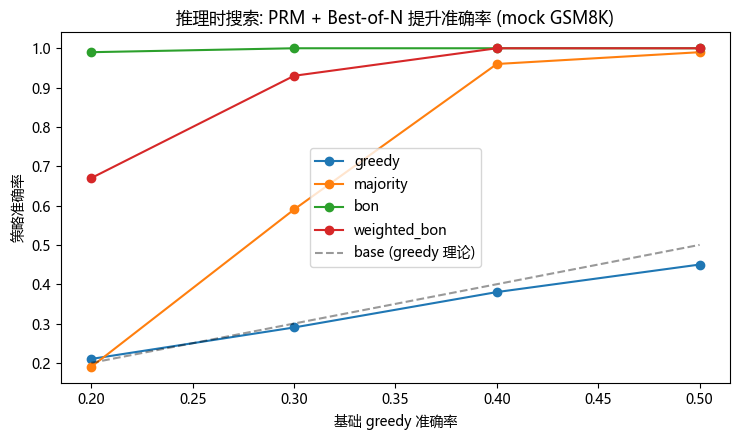

base=0.3 时: {'greedy': 0.29, 'majority': 0.59, 'bon': 1.0, 'weighted_bon': 0.93}
→ majority/BoN 都提分; PRM 加权 BoN (按过程分选) 通常最好 (本专题核心)。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
base_accs = [0.2, 0.3, 0.4, 0.5]
strategies = ['greedy','majority','bon','weighted_bon']
data = {s: [] for s in strategies}
for ba in base_accs:
    out = pb.evaluate_bon(100, 32, accuracy=ba)
    for s in strategies: data[s].append(out.get(s, 0))
plt.figure(figsize=(7.5,4.5))
for s in strategies: plt.plot(base_accs, data[s], 'o-', label=s)
plt.plot(base_accs, base_accs, 'k--', alpha=0.4, label='base (greedy 理论)')
plt.xlabel('基础 greedy 准确率'); plt.ylabel('策略准确率'); plt.legend()
plt.title('推理时搜索: PRM + Best-of-N 提升准确率 (mock GSM8K)'); plt.tight_layout(); plt.show()
print('base=0.3 时:', {s: round(data[s][1],3) for s in strategies})
print('→ majority/BoN 都提分; PRM 加权 BoN (按过程分选) 通常最好 (本专题核心)。')

> 本专题其余 src (`prm_minimal`/`math_shepherd_data_gen`/`mcts_llm`/`prime_minimal`/`rlvr_demo`/`bon_search`) 是 PRM 训练/搜索的实现。